# 03 - Duplikate auflösen und Datenbestand kuratieren
Auf Basis des vollständigen Audits werden identische Inhalte bereinigt und ein kuratierter Datenbestand erzeugt. Innerhalb derselben Klasse bleibt bei pixelidentischen Bildern ein deterministischer Vertreter erhalten. Ordnerübergreifende identische Inhalte werden vom Modellbestand ausgeschlossen. Ähnliche, aber nicht identische Bilder werden nicht gelöscht, sondern für die spätere Datenaufteilung gruppiert. Die Rohbilder bleiben unverändert.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

here = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (here, *here.parents)
                     if (p / "notebooks").is_dir() and (p / "data").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Projektordner mit notebooks/ und data/ fehlt.")
for name in ["data.py", "visual_review.py"]:
    if not (PROJECT_ROOT / "src/tlfs23" / name).is_file():
        raise FileNotFoundError(f"src/tlfs23/{name} fehlt. Dateien aus dem Paket ergänzen.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from tlfs23 import data as d, visual_review as r
from tlfs23.common import paths, read_csv

P = paths(PROJECT_ROOT)
print("Projekt:", PROJECT_ROOT)

audit = d.load_audit(PROJECT_ROOT)
print("Geprüfte Dateien:", len(audit))

Projekt: /Users/sharu/Documents/DBU/tamil-finger-sign-mlops
Geprüfte Dateien: 255158


## 1. Identische Inhalte auflösen
Pixelidentische Inhalte innerhalb derselben Klasse werden auf einen deterministisch ausgewählten Vertreter reduziert. Identische Inhalte mit unterschiedlichen Klassenordnern werden wegen des Labelkonflikts nicht für das Modell freigegeben.

In [2]:
curated, duplicate_groups = d.curate(audit)
display(curated["decision"].value_counts().rename_axis("decision").reset_index(name="n"))
print("Technische Kandidaten:", int(curated["use_for_model"].sum()))


,decision,n
0,KEEP,245074
1,EXCLUDE_EXACT_DUPLICATE,8757
2,KEEP_CANONICAL,1185
3,REVIEW_CROSS_LABEL_DUPLICATE,142


Technische Kandidaten: 246259


## 3. Identische Inhalte ansehen
Je ein Beispiel einer klasseninternen und einer klassenübergreifenden Duplikatgruppe wird visuell geprüft. Die Sichtprüfung dient ausschließlich der Plausibilisierung der hashbasierten Erkennung.


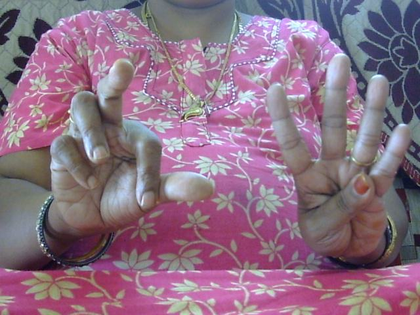
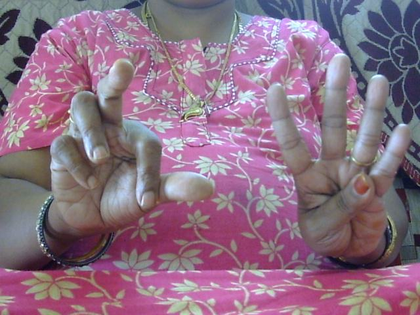


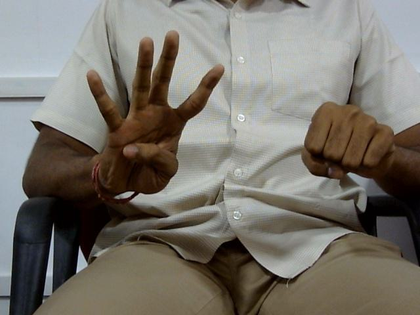
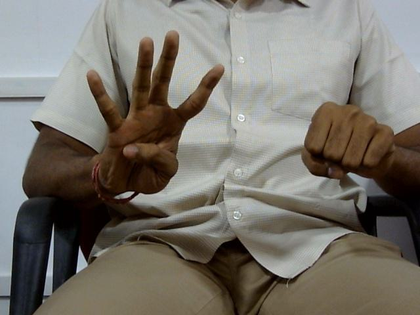

In [3]:
EXACT_GROUPS_PER_TYPE = 1
pool = r.review_pool(PROJECT_ROOT, curated)
for cross_label in [False, True]:
    groups = duplicate_groups.loc[duplicate_groups["cross_label"].eq(cross_label)]
    shown = 0
    for pixel_hash in groups["pixel_sha256"]:
        example = pool.loc[pool["pixel_sha256"].eq(pixel_hash)].sort_values("relative_path")
        if cross_label:
            example = example.drop_duplicates("dataset_folder")
        example = example.head(2)
        if len(example) < 2:
            continue
        title = "Identische Pixel in mehreren Ordnern" if cross_label else "Identische Pixel im selben Ordner"
        r.show_cards(PROJECT_ROOT, example, title, context="03_identical",
                     output_name="03_identical_" + pixel_hash[:16])
        shown += 1
        if shown >= EXACT_GROUPS_PER_TYPE:
            break

## 4. Klassenumfang und dHash-Kandidaten
Zusätzlich wird geprüft, wie stark die Bereinigung einzelne Klassen beeinflusst. Dadurch können stark betroffene Klassen vor der Datenaufteilung erkannt werden.

In [4]:
impact = curated.groupby("dataset_folder").agg(
    vorher=("relative_path", "size"), nachher=("use_for_model", "sum")
)
impact["ausgeschlossen"] = impact["vorher"] - impact["nachher"]
display(impact.sort_values("ausgeschlossen", ascending=False).head(10))
near = d.near_candidates(curated)

n_groups = len(near)
n_images = int(near["n"].sum())
n_candidates = int(curated["use_for_model"].sum())

print("dHash-Gruppen:", n_groups)
print("Bilder in dHash-Gruppen:", n_images)
print(f"Anteil an Modellkandidaten: {n_images / n_candidates:.2%}")



,vorher,nachher,ausgeschlossen
dataset_folder,,,
22,1071,973,98
28,1048,973,75
24,1071,1012,59
19,1075,1034,41
136,1018,978,40
217,1002,962,40
223,1010,971,39
129,1017,978,39
36,1057,1018,39


dHash-Gruppen: 49296
Bilder in dHash-Gruppen: 196705
Anteil an Modellkandidaten: 79.88%


In [5]:
n_groups = len(near)
n_images = int(near["n"].sum())
n_candidates = int(curated["use_for_model"].sum())

print("dHash-Gruppen:", n_groups)
print("Bilder in dHash-Gruppen:", n_images)
print(f"Anteil an Modellkandidaten: {n_images / n_candidates:.2%}")

dHash-Gruppen: 49296
Bilder in dHash-Gruppen: 196705
Anteil an Modellkandidaten: 79.88%


## 5. Ähnliche Aufnahmen nebeneinander prüfen
Ich zeige je Gruppe zwei verschiedene Pixelinhalte. Die dHash-Distanz ist hier **0**, weil nach
gleichen dHashes gesucht wird, nicht nach allen möglichen Hamming-Abständen.
`DHASH_START` wählt weitere Gruppen. Kein Bild wird aufgrund dieser Sichtprüfung automatisch ausgeschlossen.

,pair_id,dataset_folder,hamming_distance,group_size,pixel_identical
0,223da29a98abd11b,1,0,10,False
1,6329e8c8c910535e,1,0,10,False
2,8b337d4b9789d9bd,1,0,10,False
3,bd9b89bd7cd3a483,1,0,10,False



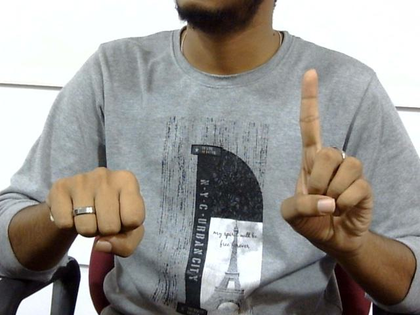
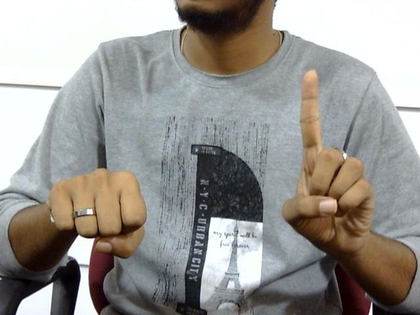


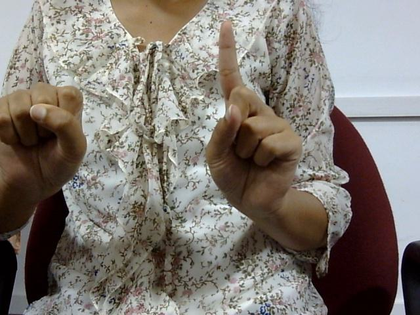
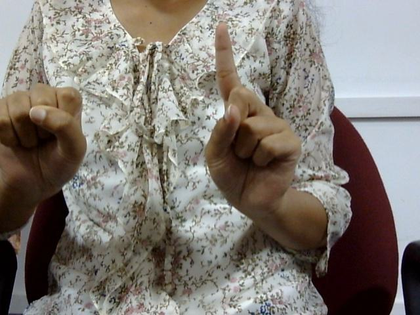


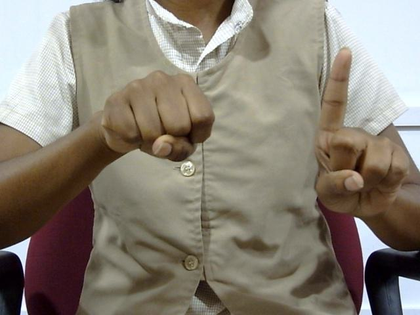
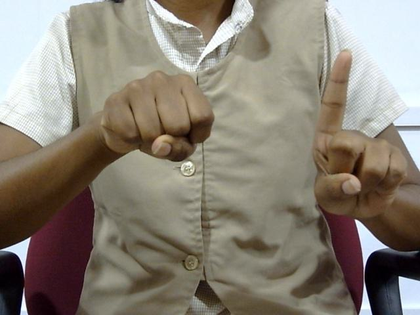


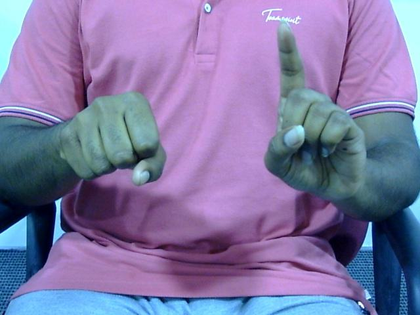
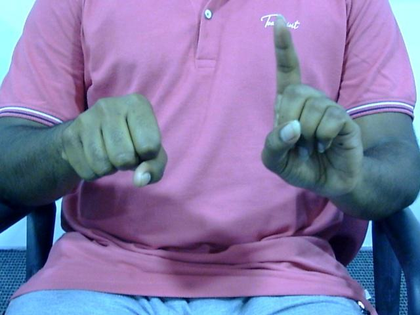

In [7]:
DHASH_PAIRS_TO_SHOW = 4

pairs = r.dhash_pairs(PROJECT_ROOT, curated, max_pairs=DHASH_PAIRS_TO_SHOW,)
display(pairs[["pair_id", "dataset_folder", "hamming_distance", "group_size", "pixel_identical"]])
r.show_pairs(PROJECT_ROOT, pairs)

## 6. Sichtbefund festhalten
Die Sichtprüfung bestätigte, dass gleiche dHashes häufig sehr ähnliche Aufnahmen repräsentieren.Bilder derselben Klasse mit identischem dHash werden nicht entfernt. Stattdessen erhalten sie eine gemeinsame Gruppen-ID, damit ähnliche Aufnahmen später nicht auf Training, Validation und Test verteilt werden. Einzelbilder erhalten jeweils eine eigene Gruppen-ID.

In [8]:
# Nur aktuell freigegebene Modellkandidaten berücksichtigen
model_mask = (
    curated["use_for_model"].fillna(False)
    & curated["dhash"].notna()
)

# Größe jeder dHash-Gruppe innerhalb einer Dataset-Klasse
group_sizes = (
    curated.loc[model_mask]
    .groupby(["dataset_folder", "dhash"])["relative_path"]
    .transform("size")
)

curated["dhash_group_size"] = 1
curated.loc[group_sizes.index, "dhash_group_size"] = group_sizes.astype(int)

# Gemeinsame Split-Gruppe für ähnliche Bilder
near_mask = (
    model_mask
    & curated["dhash_group_size"].ge(2)
)

curated["split_group_id"] = pd.NA

curated.loc[near_mask, "split_group_id"] = (
    "DHASH_"
    + curated.loc[near_mask, "dataset_folder"].astype(str)
    + "_"
    + curated.loc[near_mask, "dhash"].astype(str)
)

# Einzelbilder bekommen eine eigene Gruppe
single_mask = (
    curated["use_for_model"].fillna(False)
    & ~near_mask
)

curated.loc[single_mask, "split_group_id"] = (
    "IMAGE_"
    + curated.loc[single_mask, "relative_path"].astype(str)
)

print("Modellkandidaten:", int(curated["use_for_model"].sum()))
print("Bilder in dHash-Gruppen:", int(near_mask.sum()))
print(
    "dHash-Split-Gruppen:",
    curated.loc[near_mask, "split_group_id"].nunique()
)

Modellkandidaten: 246259
Bilder in dHash-Gruppen: 196705
dHash-Split-Gruppen: 49296


In [9]:
model_candidates = curated[curated["use_for_model"]].copy()

# 1. Jeder Modellkandidat braucht eine Split-Gruppe
missing_groups = int(model_candidates["split_group_id"].isna().sum())

# 2. Größe der Gruppen bestimmen
split_group_sizes = (
    model_candidates
    .groupby("split_group_id")
    .size()
    .sort_values(ascending=False)
)

print("Modellkandidaten ohne split_group_id:", missing_groups)
print("Split-Gruppen insgesamt:", len(split_group_sizes))
print("Größte Split-Gruppe:", int(split_group_sizes.max()))

assert missing_groups == 0, (
    "Nicht alle Modellkandidaten besitzen eine split_group_id."
)

Modellkandidaten ohne split_group_id: 0
Split-Gruppen insgesamt: 98850
Größte Split-Gruppe: 10


In [10]:
import json

split_group_manifest = (
    curated.loc[
        curated["use_for_model"],
        [
            "relative_path",
            "dataset_folder",
            "dhash",
            "dhash_group_size",
            "split_group_id",
        ],
    ]
    .copy()
    .sort_values(["dataset_folder", "split_group_id", "relative_path"])
)

# Schnittstelle zu freeze_split():
# intern heißt die Spalte split_group_id,
# im Gruppen-Manifest erwartet die Split-Funktion group_id
split_group_export = split_group_manifest.rename(
    columns={"split_group_id": "group_id"}
)

split_group_path = P["manifests"] / "split_group_manifest.csv"
split_group_export.to_csv(split_group_path, index=False)

grouping_summary = {
    "n_model_candidates": int(len(split_group_manifest)),
    "n_split_groups": int(split_group_manifest["split_group_id"].nunique()),
    "n_dhash_groups": int(
        split_group_manifest.loc[
            split_group_manifest["dhash_group_size"].ge(2),
            "split_group_id",
        ].nunique()
    ),
    "n_images_in_dhash_groups": int(
        split_group_manifest["dhash_group_size"].ge(2).sum()
    ),
    "max_group_size": int(
        split_group_manifest.groupby("split_group_id").size().max()
    ),
    "policy": "same-class equal-dHash images stay in the same split",
}

summary_path = PROJECT_ROOT / "artifacts" / "data_audit" / "03_split_group_summary.json"
summary_path.parent.mkdir(parents=True, exist_ok=True)

summary_path.write_text(
    json.dumps(grouping_summary, indent=2),
    encoding="utf-8",
)

print(grouping_summary)
print("\nGespeichert:")
print("-", split_group_path)
print("-", summary_path)

required_group_columns = {
    "dhash_group_size",
    "split_group_id",
}

missing = required_group_columns - set(curated.columns)

print("Fehlende Gruppierungs-Spalten:", missing)

assert not missing, (
    f"Diese Spalten fehlen noch im curated DataFrame: {sorted(missing)}"
)

print("Gruppierungsinformationen sind im curated DataFrame enthalten.")

{'n_model_candidates': 246259, 'n_split_groups': 98850, 'n_dhash_groups': 49296, 'n_images_in_dhash_groups': 196705, 'max_group_size': 10, 'policy': 'same-class equal-dHash images stay in the same split'}

Gespeichert:
- /Users/sharu/Documents/DBU/tamil-finger-sign-mlops/data/manifests/tlfs23/split_group_manifest.csv
- /Users/sharu/Documents/DBU/tamil-finger-sign-mlops/artifacts/data_audit/03_split_group_summary.json
Fehlende Gruppierungs-Spalten: set()
Gruppierungsinformationen sind im curated DataFrame enthalten.


## 7. Kuratierten Datenstand speichern
Das Manifest bestimmt die weitere Verwendung. Angezeigte Bilder werden zusätzlich in
`visual_review_exposure.csv` erfasst und in Notebook 04 vom neuen Holdout und der Validation ferngehalten.
Ein bereits fester Split wird bei der Bildauswahl geschützt.

In [11]:
summary = d.save_curation(
    PROJECT_ROOT,
    curated,
    duplicate_groups
)

impact.to_csv(
    P["manifests"] / "curation_by_folder.csv"
)

manifest_path = P["manifests"] / "curation_manifest.csv"
split_group_path = P["manifests"] / "split_group_manifest.csv"
grouping_summary_path = (
    PROJECT_ROOT
    / "artifacts"
    / "data_audit"
    / "03_split_group_summary.json"
)

# Prüfen, ob die neuen Gruppierungsinformationen
# auch im gespeicherten Curation-Manifest enthalten sind
saved_manifest = read_csv(manifest_path)

required_columns = {
    "dhash_group_size",
    "split_group_id",
}

missing = required_columns - set(saved_manifest.columns)

if missing:
    raise ValueError(
        f"Gruppierungsinformationen fehlen im gespeicherten Manifest: "
        f"{sorted(missing)}"
    )

print("Modellkandidaten:", summary["n_candidates"])
print("Curation gespeichert.")

Modellkandidaten: 246259
Curation gespeichert.


## Ergebnis

Von 255.158 auditierten Bildern wurden 246.259 als Modellkandidaten freigegeben. Pixelidentische Duplikate innerhalb derselben Klasse wurden auf einen Vertreter reduziert. 142 klassenübergreifende identische Dateien wurden wegen des Labelkonflikts ausgeschlossen. Zusätzlich wurden 49.296 dHash-Gruppen mit 196.705 Bildern identifiziert. Diese Bilder werden nicht entfernt, sondern über gemeinsame Gruppen-IDs für die spätere Datenaufteilung zusammengehalten. Dadurch soll verhindert werden, dass sehr ähnliche Aufnahmen über Training, Validation und Test verteilt werden.